In [1]:
# import packages
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import xarray as xr
import flowkit as fk
import glob
import os
import math
from scipy.stats import linregress, ttest_ind, f_oneway, pearsonr

%matplotlib ipympl

In [2]:
# set parameters for plots/visualization
SMALL_SIZE = 7
MEDIUM_SIZE = 7
BIGGER_SIZE = 7

plt.rcParams['svg.fonttype'] = 'none'    # makes text editable in exported .svg files
plt.rcParams['font.sans-serif'] = 'Arial'# set font for all plots to Arial

plt.rc('font', family='Arial')
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [3]:
# load data
data = pd.concat([pd.read_csv(f) for f in glob.glob('./*.csv')])
data = data.set_index(list('ESR')+['CellID'])

summaries = pd.concat([pd.read_csv(f) for f in glob.glob('./**', recursive = True) if 'gating_summary' in f]).set_index('S')
summaries

,Event Count,g1 fraction,g2 fraction of g1,g2 fraction of all events
S,,,,
aC2_FL_+_unstained,52954.0,0.072176,0.998430,0.072063
aC2_FL_+_stained,48362.0,0.072557,0.997435,0.072371
gC3_FL_+_EC6_a4_stained,69810.0,0.434178,0.998317,0.433448
a4_dCyto_+_EC56_gC3_stained,72006.0,0.440338,0.997666,0.439311
gC3_FL_+_stained,58079.0,0.445962,0.998803,0.445428
...,...,...,...,...
a4_dCyto_+_EC56_gC3_stained,94112.0,0.738620,0.999122,0.737972
a4_dCyto_+_EC56_gC3_unstained,95834.0,0.742440,0.999072,0.741751
a4_dCyto_+_EC6_gC3_unstained,95302.0,0.759596,0.999074,0.758893


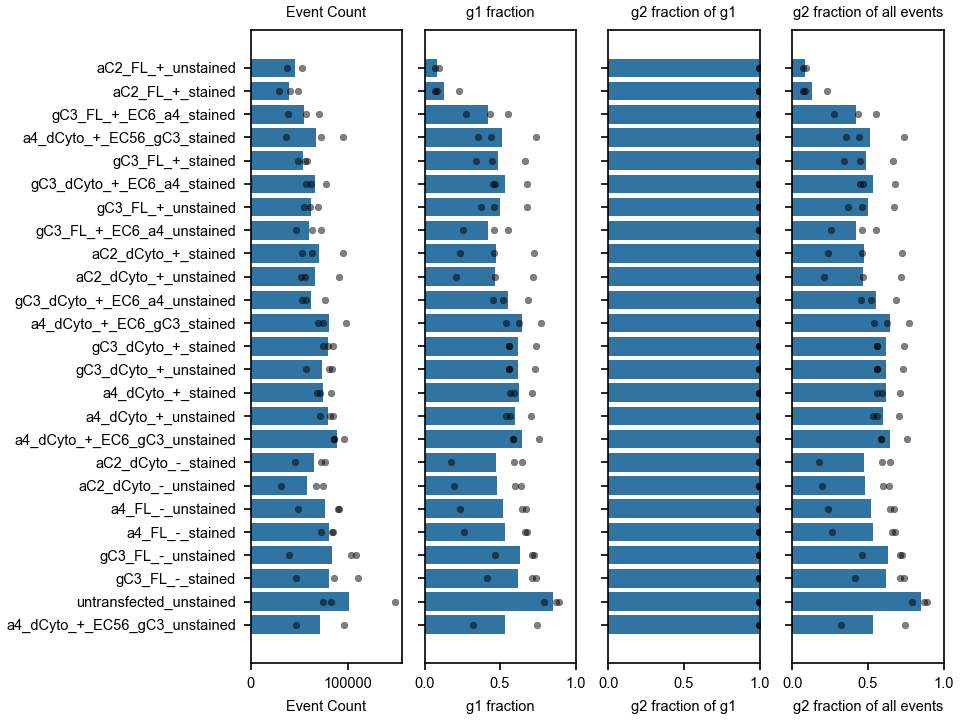

In [58]:
fig, axs = plt.subplots(1,4, layout = 'constrained', dpi = 150, sharey = True)
for col, ax in zip(summaries.columns, axs):
    sns.barplot(summaries, x = col, y = 'S', ax = ax, errorbar=None)
    sns.scatterplot(summaries, x = col, y = 'S', ax = ax, ec = None, s = 10, color = 'k', alpha = 0.5)
    ax.set_title(col)
    ax.set_ylabel(None)
    if col != 'Event Count':
        ax.set_xlim(0,1)
plt.show()

In [64]:
summaries['g1 fraction'].loc[[
    name for name in summaries.index if 'aC2' not in name and 'untransfected' not in name
]].groupby('S').max().max()

0.7691683861496925

In [5]:
data = data.rename(columns= {'BL1-H' : 'FITC', 'YL1-H' : 'mCherry'})

In [6]:
# thresholding (note that threshold values are calcuated from the entire data set)
tthr = data['mCherry'].xs('untransfected_unstained', level = 'S').quantile(0.995) # transfection threshold
controls = [name for name in data.index.unique('S') if ('_unstained' in name and 'untransfected' not in name) or '_-_' in name]
sthr = data['FITC'].loc[pd.IndexSlice[:,controls]].quantile(0.995) # surface stain threshold

In [7]:
# printing sample names as they were recorded with the data
data.index.unique('S')

Index(['a4_dCyto_+_unstained', 'gC3_FL_-_unstained',
       'gC3_FL_+_EC6_a4_unstained', 'aC2_FL_+_stained', 'a4_dCyto_+_stained',
       'gC3_FL_+_stained', 'aC2_dCyto_-_unstained', 'untransfected_unstained',
       'gC3_FL_-_stained', 'a4_FL_-_unstained', 'a4_dCyto_+_EC6_gC3_stained',
       'aC2_dCyto_+_stained', 'gC3_dCyto_+_unstained',
       'gC3_dCyto_+_EC6_a4_unstained', 'a4_dCyto_+_EC56_gC3_stained',
       'a4_dCyto_+_EC56_gC3_unstained', 'a4_dCyto_+_EC6_gC3_unstained',
       'gC3_FL_+_EC6_a4_stained', 'gC3_FL_+_unstained', 'aC2_dCyto_-_stained',
       'gC3_dCyto_+_EC6_a4_stained', 'aC2_dCyto_+_unstained',
       'gC3_dCyto_+_stained', 'a4_FL_-_stained', 'aC2_FL_+_unstained'],
      dtype='object', name='S')

In [8]:
# quantile binning based on all transfected cells in the dataset
transfected = data[data['mCherry'] > tthr].drop('untransfected_unstained', level = 'S') # dataframe of transfected cells
transfected = transfected[(transfected['mCherry'] > 0) & (transfected['FITC'] > 0)]
transfected['bin'], bins = pd.qcut(transfected['mCherry'], 50, retbins = True)

In [9]:
# function for calculating the bin means (FP and Ab) and linear fit parameters for subsets of data
def binning(df, bins, gpby):
    """
    Parameters
    ----------
    
    df : pd.DataFrame
        Subset of the data to split among bins.
    bins : array
        Array of values that define the edges of the bins. Has length nbins + 1.
    gpby : index level name or list of names
        'group by'; specifies which index levels to use for combining data.
        e.g. use 'list("ES")' to perform calculations separately for each experiment and sample, or
        e.g. use 'S' to aggregate all experiments together by sample.
        
    Returns
    -------
    
    binned : pd.DataFrame
        Dataframe with the information as the input df but additionally
        specifying 'bin', 'FPbin', and 'Abbin' values for each cell.
    lr : pd.DataFrame
        Dataframe containing the linear regression fit parameters.
    """
    
    if 'untransfected_unstained' in df.index.unique('S'):
        df = df.drop('untransfected_unstained', level = 'S')

    binmeans = df.groupby(gpby).apply(lambda x: x.groupby(pd.cut(x['mCherry'], bins).rename('B'), observed = False).mean()).rename(columns = {'mCherry' : 'FPbin', 'FITC' : 'Abbin'})

    lr = binmeans[binmeans['Abbin'] >= 0].groupby(gpby).apply(lambda x: linregress(np.log(x['FPbin']),np.log(x['Abbin'])))
    # Note that bins with mean Abbin values equal to or below zero are excluded from the linear fit.
    # Mean FPbin values will never be equal to or below zero because tthr is greater than zero.
    lines = pd.DataFrame(index = lr.index, columns = ['slope', 'intercept', 'r', 'p', 'stderr'])
    for k, col in enumerate(lines.columns):
        lines[col] = [lr[j][k] for j in lr.index]
        
    return binmeans, lines

In [10]:
def quickplot(subset, norm_sample = 'gC3_FL_+_stained', reorder = False, limitx = True, height = 3, width = 6.5):
    
    t = subset['mCherry'] > tthr
    s = subset['FITC'] > sthr
    
    transfected = subset[t]
    transfected = transfected[(transfected['mCherry'] > 0) & (transfected['FITC'] > 0)]
    
    sde_es = (t&s)[t].groupby(list('ES')).mean()
    sde_es.name = 'FITC'
    sde_s = (t&s)[t].groupby('S').mean()
    sde_s.name = 'FITC'

    norm = transfected['FITC'].xs(norm_sample, level = 'S').mean()
    ab_es = transfected['FITC'].groupby(list('ES')).mean()/norm
    ab_s = transfected['FITC'].groupby('S').mean()/norm

    bn_es, E_es = binning(transfected, bins, list('ES'))
    bn_s, E_s = binning(transfected, bins, 'S')
    
    if reorder:
        order = subset.index.unique('S')[reorder]
    else:
        order = subset.index.unique('S')
    
    fig, axs = plt.subplots(1,3,layout = 'constrained', figsize = (width, height), sharey = True)

    for ax, each, name, plot, top in zip(
        axs,
        [(sde_es, sde_s), (ab_es, ab_s), (E_es['slope'], E_s['slope'])],
        ['FITC', 'FITC','slope'],
        [r'$f^+$', r'$\overline{Ab}$', r'$E_{surface}$'],
        ['Stained cell fraction', r'Mean Ab$_{cell}$ signal', 'Slope of dose-response'], ):

        sns.barplot(
            data = each[1].loc[order].reset_index(),
            y = 'S',
            x = name,
            ax = ax,
            color = '#969696',
            # hue = 'S', palette = [clrd[j] for j in each[1].reset_index()['S']],
        )
        sns.swarmplot(
            data = each[0].loc[pd.IndexSlice[:,order]].reset_index(),
            y = 'S',
            x = name,
            ax = ax,
            s = 3,
            color = 'k',
        )
        ax.set_ylabel(None)
        # ax.set_yticks(ax.get_yticks(), [sample_dictionary[o] for o in each[1].loc[order].reset_index()['S']])
        ax.spines[['top','right']].set_visible(False)
        ax.set_xlabel(plot)
        ax.set_title(top)
    
#     if limitx:
#         axs[0].set_xlim(0,1)

    plt.show()
    
    return [sde_es, sde_s, ab_es, ab_s, E_es, E_s, bn_es, bn_s, transfected, t, s]

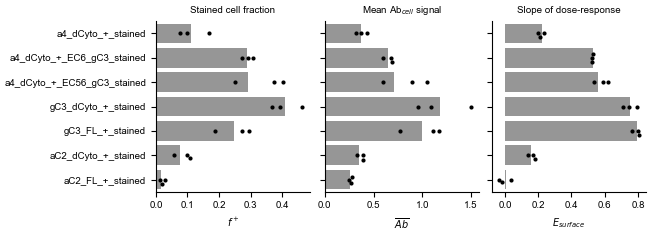

In [11]:
df = data.drop('untransfected_unstained', level = 'S')
stained_tagged = [smpl for smpl in df.index.unique('S') if '_+_' in smpl and '_stained' in smpl and not 'EC6_a4' in smpl]
stained_tagged = [stained_tagged[j] for j in [1,3,5,-1,2,4,0]]
stained = df.loc[pd.IndexSlice[:,stained_tagged,:]]
show = quickplot(stained, height = 2.3522, width = 6.5)
plt.savefig('flow_data_quickplot.svg')

In [12]:
sde_es, sde_s, ab_es, ab_s, E_es, E_s, bn_es, bn_s, transfected, t, s = show

In [13]:
def get_pvalues(ser):
    return ser.groupby('S').apply(lambda x: ttest_ind(x, ser.xs('a4_dCyto_+_stained', level = 'S'), alternative = 'greater').pvalue)

In [14]:
get_pvalues(sde_es)

S
a4_dCyto_+_EC56_gC3_stained    0.006466
a4_dCyto_+_EC6_gC3_stained     0.001904
a4_dCyto_+_stained             0.500000
aC2_FL_+_stained               0.986655
aC2_dCyto_+_stained            0.767583
gC3_FL_+_stained               0.016186
gC3_dCyto_+_stained            0.000898
Name: FITC, dtype: float64

In [15]:
get_pvalues(ab_es)

S
a4_dCyto_+_EC56_gC3_stained    0.012284
a4_dCyto_+_EC6_gC3_stained     0.001421
a4_dCyto_+_stained             0.500000
aC2_FL_+_stained               0.986641
aC2_dCyto_+_stained            0.535801
gC3_FL_+_stained               0.003792
gC3_dCyto_+_stained            0.004472
Name: FITC, dtype: float64

In [16]:
get_pvalues(E_es['slope'])

S
a4_dCyto_+_EC56_gC3_stained    0.000074
a4_dCyto_+_EC6_gC3_stained     0.000005
a4_dCyto_+_stained             0.500000
aC2_FL_+_stained               0.999630
aC2_dCyto_+_stained            0.980168
gC3_FL_+_stained               0.000002
gC3_dCyto_+_stained            0.000019
Name: slope, dtype: float64

In [17]:
def logticks(ax, xaxis = True, yaxis = True):
    
    tickrange = np.array([-100, -10, 1, 10, 100, 1000, 10000, 100000, 1000000])
    minorticks = np.array([np.arange(0,n,n/10)[1:] for n in tickrange[tickrange > 0]]).ravel()
    
    if xaxis: 
        minx, maxx = [np.e**j for j in ax.get_xlim()]
        xticks = np.array([x for x in tickrange if x > minx and x < maxx])
        ax.set_xticks(np.log(xticks), xticks)
        
        minorxticks = np.array([x for x in minorticks if x > minx and x < maxx])
        ax.xaxis.set_minor_locator(FixedLocator(np.log(minorxticks)))
        
    if yaxis:
        miny, maxy = [np.e**j for j in ax.get_ylim()]
        yticks = np.array([y for y in tickrange if y > miny and y < maxy])
        ax.set_yticks(np.log(yticks), yticks)
        
        minoryticks = np.array([y for y in minorticks if y > miny and y < maxy])
        ax.yaxis.set_minor_locator(FixedLocator(np.log(minoryticks)))

In [18]:
hist_kws = {
    # 'legend' : True,
    'common_bins' : True,
    'element' : 'step',
    'common_norm' : False,
    'stat' : 'density',
    'kde' : False,
    'fill' : False,
    'common_norm' : False,
    # 'hue_order' : smpl,
    # 'palette' : pal,
    'kde' : False
}

In [19]:
# f+ (surface delivery efficiency) divided by experiment and sample
sde_es
sde_es.to_csv('./calc_metrics/f+_es.csv')

In [20]:
# f+ (surface delivery efficiency) divided by sample
sde_s
sde_s.to_csv('./calc_metrics/f+_s.csv')

In [21]:
# Ab_bar (mean surface signal) dividied by experiment and sample
ab_es
ab_es.to_csv('./calc_metrics/ab-bar_es.csv')

In [22]:
# Ab_bar (mean surface signal) divided by sample
ab_s
ab_s.to_csv('./calc_metrics/ab-bar_s.csv')

In [23]:
# E_surface (surface delivery efficiency) dividied by experiment and sample
E_es
E_es.to_csv('./calc_metrics/E-surface_es.csv')

In [24]:
# E_surface (surface delivery efficiency) divided by sample
E_s
E_s.to_csv('./calc_metrics/E-surface_s.csv')

In [25]:
sel_isoforms = [name for name in stained.index.unique('S') if 'EC' not in name]
sel_isoforms

['a4_dCyto_+_stained',
 'gC3_dCyto_+_stained',
 'gC3_FL_+_stained',
 'aC2_dCyto_+_stained',
 'aC2_FL_+_stained']

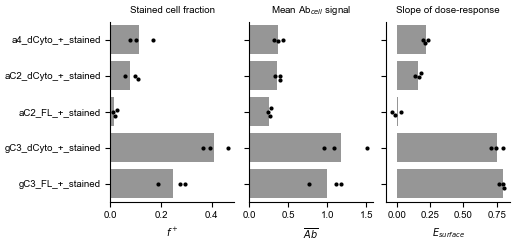

In [45]:
quickplot(stained.loc[pd.IndexSlice[:,sel_isoforms],:], width = 5.14, height = 2.45, reorder = [0,-2,-1,1,2])
plt.savefig('flow_ICD_compare.svg', dpi = 300)